In [1]:
library(limma)
library(reshape2)
library(gridExtra)

source("../../evaluation_utils/plots/eda_plots.R")
source("../../evaluation_utils/filtering/filtering_normalization.R")
source("../../evaluation_utils/evaluation/DE_analysis.R")
source("../../evaluation_utils/plots/DE_plots.R")
source("../../evaluation_utils/simulation/simulation_func.R")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::combine() masks gridExtra::combine()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose


The following objects are masked from ‘package:reshape2’:

    dcast, melt



Attaching packag

# settings

In [2]:
check_dirs <- function(workdir){
    if (!dir.exists(workdir)){
        dir.create(workdir,recursive = TRUE)
    }
}

In [3]:
data_directory <- "/home/yuliya/repos/cosybio/FedProt/data/simulated_scaled/"
workdir <- "/home/yuliya/repos/cosybio/FedProt/evaluation/simulated_scaled/"

number_of_runs = 10

In [6]:
modes_list <- c(
    # "balanced_1x", "balanced_10x", 
    "balanced_100x",
    # "strong_imbalanced_1x", "strong_imbalanced_10x", 
    # "strong_imbalanced_100x"
)

# Central and labs separately analysis

Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Filtering out features that have NAs in all columns
	Before filtering: 6000 6600 
	After filtering: 6000 6600 
Filtering by condition - two not-NA per condition
	Before filtering: 6000 6600 
	After filtering: 6000 6600 
Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Filtering out features that have NAs in all columns
	Before filtering: 6000 6600 
	After filtering: 6000 6600 
Filt

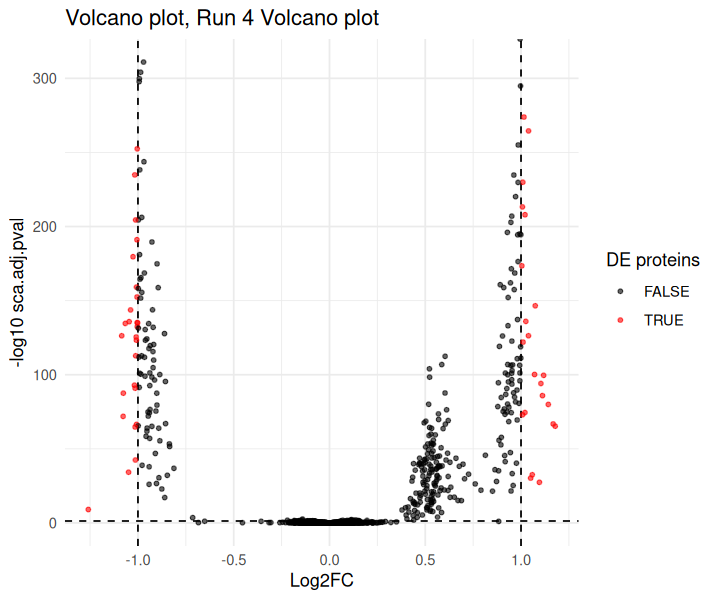

Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Filtering out features that have NAs in all columns
	Before filtering: 6000 6600 
	After filtering: 6000 6600 
Filtering by condition - two not-NA per condition
	Before filtering: 6000 6600 
	After filtering: 6000 6600 
Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Filtering out features that have NAs in all columns
	Before filtering: 6000 6600 
	After filtering: 6000 6600 
Filt

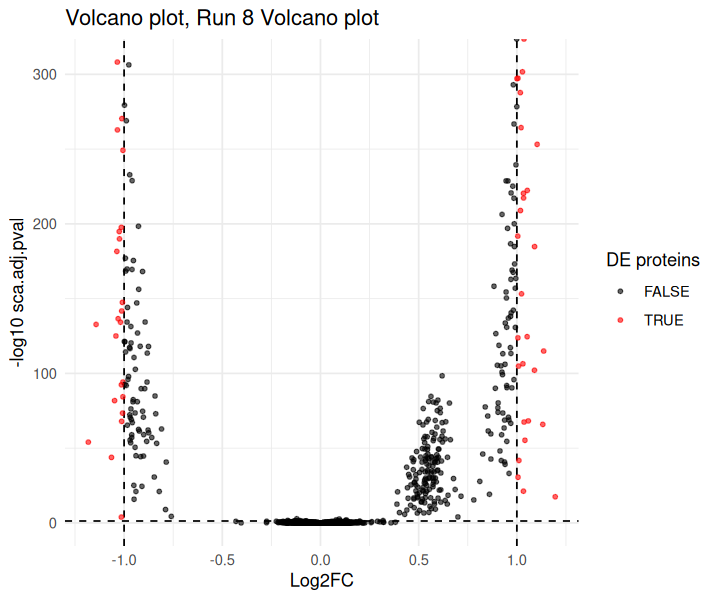

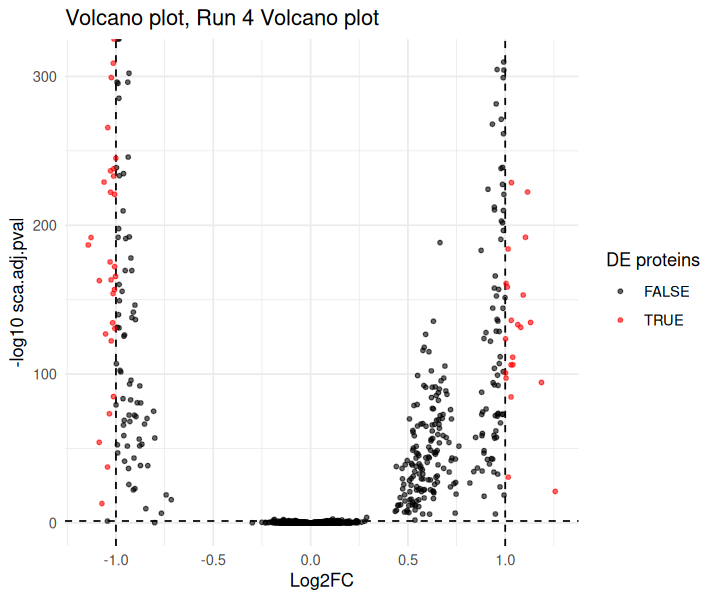

Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Filtering out features that have NAs in all columns
	Before filtering: 6000 6600 
	After filtering: 6000 6600 
Filtering by condition - two not-NA per condition
	Before filtering: 6000 6600 
	After filtering: 6000 6600 
Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Count information is not available
Using P.Value and adj.P.Val as sca.P.Value and sca.adj.pval
Filtering out features that have NAs in all columns
	Before filtering: 6000 6600 
	After filtering: 6000 6600 
Filt

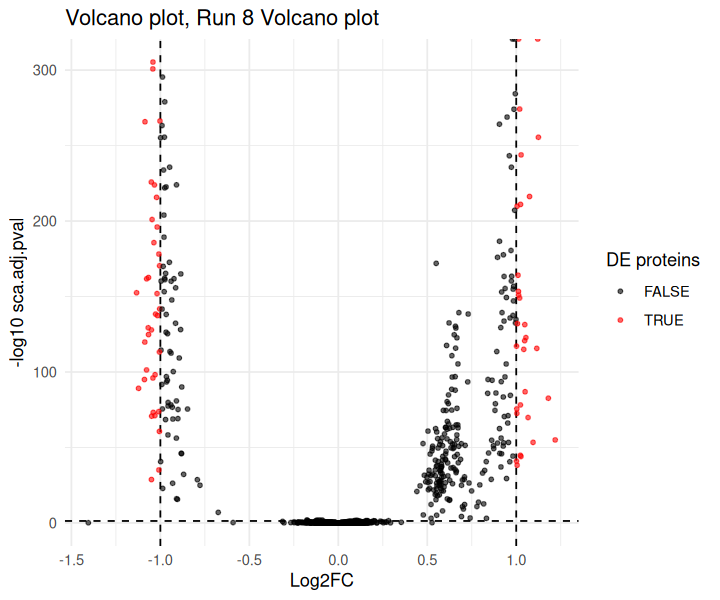

In [11]:
for (mode in modes_list){
    sub_path = mode

    generated_data_directory <- paste0(data_directory, sub_path, "/data")
    meta_output_dir <- paste0(workdir, sub_path, "/meta/")
    de_output_dir <- paste0(workdir, sub_path, "/results")
    check_dirs(meta_output_dir)
    check_dirs(de_output_dir)

    # run DEqMS
    # read batch info
    batch_info <- read.table(paste0(generated_data_directory, "/batch_info.tsv"), sep = "\t", header = TRUE)
    batch_info <- batch_info %>%
        mutate(lab = as.factor(batch), condition = as.factor(condition))

    for(j in 1:number_of_runs){
        i = 1
        
        if(j %% 4 == 0){
            print(paste0("Run number ", j))
        }
        # read data
        lab1_data <- read.table(paste0(generated_data_directory, "/",  j, "_lab_1_intensities_data.tsv"), sep = "\t", header = TRUE, row.names = 1)
        lab2_data <- read.table(paste0(generated_data_directory, "/",  j, "_lab_2_intensities_data.tsv"), sep = "\t", header = TRUE, row.names = 1)
        lab3_data <- read.table(paste0(generated_data_directory, "/",  j, "_lab_3_intensities_data.tsv"), sep = "\t", header = TRUE, row.names = 1)

        # run DEqMS separately for each lab
        design <- model.matrix(~0 + batch_info$condition)
        colnames(design) <- levels(as.factor(batch_info$condition))
        rownames(design) <- batch_info$file

        # write design matrix for each lab
        write.table(design[batch_info[batch_info$batch == "batch1",]$file, ], 
                    paste0(generated_data_directory, "/",  j, "_lab_1_design.tsv"), sep = "\t")
        write.table(design[batch_info[batch_info$batch == "batch2",]$file, ],
                    paste0(generated_data_directory, "/",  j, "_lab_2_design.tsv"), sep = "\t")
        write.table(design[batch_info[batch_info$batch == "batch3",]$file, ],
                    paste0(generated_data_directory, "/",  j, "_lab_3_design.tsv"), sep = "\t")


        contrasts <- makeContrasts(A - B, levels = colnames(design))
        for(batch in 1:3){
            lab_data <- get(paste0("lab", batch, "_data"))
            lab_design <- design[batch_info[batch_info$batch == paste0("batch", batch),]$file, ]
            lab_contrasts <- makeContrasts(A - B, levels = colnames(lab_design))
            de_results <- run_DE(lab_data, NULL, lab_design, lab_contrasts)
            write.table(
                de_results, 
                paste0(meta_output_dir, "/", j, "_lab", batch, "_res.tsv"), sep = "\t")
        }

        # Run central analysis
        design <- model.matrix(~0 + batch_info$condition + batch_info$lab)
        colnames(design) <- c(levels(batch_info$condition), levels(batch_info$lab)[-1])
        rownames(design) <- batch_info$file

        # lab1_data <- lab1_data[rownames(lab3_data),] 
        # lab2_data <- lab2_data[rownames(lab3_data),]

        # joined_data <- cbind(lab1_data, lab2_data, lab3_data) %>% as.data.frame()
        # full join to keep all proteins
        joined_data <- merge(
                merge(lab1_data, lab2_data, by = "row.names", all = TRUE) %>% column_to_rownames("Row.names"),
            lab3_data,, by = "row.names", all = TRUE) %>% column_to_rownames("Row.names")
        joined_data <- joined_data[,rownames(design)]

        joined_data <- filter_na_proteins(joined_data, batch_info, 'file')
        joined_data <- filter_by_condition(joined_data, batch_info, 
            'file', c('A', 'B'), 'condition')

        # run DEqMS for joined data    
        contrasts <- makeContrasts(A - B, levels = colnames(design))
        de_results <- run_DE(joined_data, NULL, design, contrasts)
        write.table(
            de_results, 
            paste0(de_output_dir, "/", j, "_res.tsv"), sep = "\t")
    
    if(j %% 4 == 0){
        # plot volcano plot
        plot_result <- volcano_plot(
            de_results, 
            title = paste0("Run ", j, " Volcano plot"), 
            pval_threshold = 0.05, logfc_threshold = 1,
            show_names = FALSE)
        ggsave(
            file = paste0(de_output_dir, "/", j, "_volcano_plot.jpg"), 
            plot = plot_result, width = 7, height = 5)

        options(repr.plot.width=6, repr.plot.height=5)
        print(plot_result)
        }
    }

}

# Meta-analysis

In [5]:
for (mode in modes_list){ 
  command <- paste(
    "/home/yuliya/repos/cosybio/FedProt/evaluation/simulated/run_meta_analysis.sh",
    workdir,
    mode,
    number_of_runs,
    sep = " "
  )
  print(command)
  system(command)
}

[1] "/home/yuliya/repos/cosybio/FedProt/evaluation/simulated/run_meta_analysis.sh /home/yuliya/repos/cosybio/FedProt/evaluation/simulated_scaled/ strong_imbalanced_100x 10"


# FedProt

In [8]:
for (mode in modes_list){ 
  command <- paste(
    "/home/yuliya/repos/cosybio/FedProt/evaluation/simulated/run_fedprot.sh",
    data_directory,
    workdir,
    mode,
    number_of_runs,
    sep = " "
  )
  print(command)
  system(command)
}

[1] "/home/yuliya/repos/cosybio/FedProt/evaluation/simulated/run_fedprot.sh /home/yuliya/repos/cosybio/FedProt/data/simulated_scaled/ /home/yuliya/repos/cosybio/FedProt/evaluation/simulated_scaled/ balanced_100x 10"
[1] "/home/yuliya/repos/cosybio/FedProt/evaluation/simulated/run_fedprot.sh /home/yuliya/repos/cosybio/FedProt/data/simulated_scaled/ /home/yuliya/repos/cosybio/FedProt/evaluation/simulated_scaled/ strong_imbalanced_100x 10"


In [ ]:
# all versions of all used packages print
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 24.04.1 LTS

Matrix products: default
BLAS/LAPACK: /home/yuliya/miniforge3/envs/FedProt/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Berlin
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] RobNorm_0.1.0     invgamma_1.1      ggrepel_0.9.6     DEqMS_1.20.0     
 [5] matrixStats_1.5.0 foreach_1.5.2     data.table_1.16.4 patchwork_1.3.0  
 [9] lubridate_1.9.4   forcats_1.0.0     stringr_1.5.1 